In [102]:
# 1D ResNet for 8-Channel EMG Classification

# %%
import os
from glob import glob
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set device (uses GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [103]:
# CONFIGURATION
CSV_FILES = "dataset/*.csv"

# Canonical class names for training and confusion matrix
CLASS_NAMES = ['fist', 'double_fist', 'up', 'down', 'left', 'right', 'rest']

# Map label variants from different CSV files into the same 7 classes
LABEL_ALIASES = {
    'fist': 'fist',
    'fist_close': 'fist',
    'double_fist': 'double_fist',
    'double_fist_close': 'double_fist',
    'up': 'up',
    'down': 'down',
    'left': 'left',
    'right': 'right',
    'rest': 'rest',
}

NUM_CHANNELS = 8
SAMPLE_RATE = 500
WINDOW_MS = 200
STRIDE_MS = 50

# Calculate samples
WINDOW_SAMPLES = int((WINDOW_MS / 1000.0) * SAMPLE_RATE)  # 100 samples
STRIDE_SAMPLES = int((STRIDE_MS / 1000.0) * SAMPLE_RATE)  # 25 samples

def resolve_csv_files(csv_inputs):
    if isinstance(csv_inputs, str):
        csv_inputs = [csv_inputs]

    if not csv_inputs:
        raise ValueError("Please provide at least one CSV file or pattern.")

    resolved_files = []
    for item in csv_inputs:
        matches = sorted(glob(item))
        if matches:
            resolved_files.extend(matches)
        elif os.path.exists(item):
            resolved_files.append(item)
        else:
            raise FileNotFoundError(f"Could not find any CSV files for: {item}")

    resolved_files = list(dict.fromkeys(resolved_files))
    if not resolved_files:
        raise FileNotFoundError("No CSV files were found.")

    return resolved_files

def normalize_label(label):
    cleaned = str(label).strip().lower().replace('-', '_').replace(' ', '_')
    while '__' in cleaned:
        cleaned = cleaned.replace('__', '_')

    if cleaned not in LABEL_ALIASES:
        raise ValueError(
            f"Unknown label '{label}' after cleaning to '{cleaned}'. "
            f"Add it to LABEL_ALIASES if it should map to one of {CLASS_NAMES}."
        )

    return LABEL_ALIASES[cleaned]

def load_and_window_data(csv_inputs):
    csv_files = resolve_csv_files(csv_inputs)
    ch_cols = [f'Ch{i}' for i in range(1, NUM_CHANNELS + 1)]
    required_cols = ch_cols + ['Label', 'Trial_ID']

    all_frames = []
    print("Loading data from:")
    for file_idx, csv_path in enumerate(csv_files):
        print(f" - {csv_path}")
        df = pd.read_csv(csv_path)

        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"{csv_path} is missing required columns: {missing_cols}")

        df = df.copy()
        raw_labels = sorted(df['Label'].astype(str).unique())
        print(f"   Raw labels: {raw_labels}")
        df['Label'] = df['Label'].apply(normalize_label)
        df['Source_File_ID'] = file_idx
        all_frames.append(df)

    df_all = pd.concat(all_frames, ignore_index=True)

    # Fit one scaler across the full combined dataset for consistent normalization.
    scaler = StandardScaler()
    df_all[ch_cols] = scaler.fit_transform(df_all[ch_cols])

    X_list, y_list = [], []

    # Keep windows separate across files, labels, and trials.
    for (_, label, trial), group in df_all.groupby(['Source_File_ID', 'Label', 'Trial_ID'], sort=False):
        data = group[ch_cols].values  # Shape: (time_steps, 8)

        for start in range(0, len(data) - WINDOW_SAMPLES + 1, STRIDE_SAMPLES):
            window = data[start : start + WINDOW_SAMPLES]
            X_list.append(window.T)
            y_list.append(label)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)
    print(f"Clean labels used: {sorted(np.unique(y))}")
    print(f"CSV files loaded: {len(csv_files)}")
    print(f"Total Windows Extracted: {X.shape[0]}")
    print(f"Data Shape (Windows, Channels, Samples): {X.shape}")
    return X, y, scaler

# --- LOAD ACTUAL DATA ---
X, y, scaler = load_and_window_data(CSV_FILES)

Loading data from:
 - dataset\emg_data_Akib1_20260401_152355.csv
   Raw labels: ['Double fist', 'Down', 'Fist', 'Left', 'Rest', 'Right', 'Up']
 - dataset\emg_data_Akib3_20260403_002355.csv
   Raw labels: ['Double Fist', 'Down', 'Fist', 'Left', 'Rest', 'Right', 'Up']
 - dataset\emg_data_Akib_02-04-26_20260402_161720.csv
   Raw labels: ['Down', 'Left', 'Rest', 'Right', 'Up', 'double fist', 'fist']
 - dataset\emg_data_Iftekhar3_20260401_151451.csv
   Raw labels: ['Double_Fist_Close', 'Down', 'Fist_Close', 'Left', 'Rest', 'Right', 'Up']
Clean labels used: [np.str_('double_fist'), np.str_('down'), np.str_('fist'), np.str_('left'), np.str_('rest'), np.str_('right'), np.str_('up')]
CSV files loaded: 4
Total Windows Extracted: 5078
Data Shape (Windows, Channels, Samples): (5078, 8, 100)


In [104]:
# Encode cleaned labels to integers in a fixed order
classes = CLASS_NAMES.copy()
present_classes = sorted(np.unique(y))
unexpected_classes = [c for c in present_classes if c not in classes]
if unexpected_classes:
    raise ValueError(f"Unexpected cleaned classes found: {unexpected_classes}")

missing_classes = [c for c in classes if c not in present_classes]
if missing_classes:
    print(f"Warning: these classes are not present in the loaded data: {missing_classes}")

print(f"Final class order: {classes}")
class_to_idx = {c: i for i, c in enumerate(classes)}
y_idx = np.array([class_to_idx[label] for label in y], dtype=np.int64)

# Train/Val/Test Split (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_idx, test_size=0.30, random_state=42, stratify=y_idx)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]} | Val size: {X_val.shape[0]} | Test size: {X_test.shape[0]}")

# Create PyTorch DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=batch_size, shuffle=False)


Final class order: ['fist', 'double_fist', 'up', 'down', 'left', 'right', 'rest']
Train size: 3554 | Val size: 762 | Test size: 762


In [105]:
# Define the 1D ResNet Architecture
# Uses Skip Connections (Residual Blocks) to allow deep feature extraction without 
# losing the original signal context. Restored optimal Dropout/Weight Decay.


class ResidualBlock(nn.Module):
    """A standard ResNet block tailored for 1D signals."""
    def __init__(self, channels, kernel_size=5, padding=2):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
        
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        residual = x  # Save the original signal
        
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        out += residual  # Skip Connection: Add original signal back in!
        out = self.relu(out)
        return out


class EMG_1D_ResNet(nn.Module):
    def __init__(self, num_classes, in_channels=8, window_samples=100):
        super(EMG_1D_ResNet, self).__init__()
        
        # 1. Initial Convolution (Expands channels)
        self.conv_init = nn.Conv1d(in_channels, 64, kernel_size=7, padding=3)
        self.bn_init = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.pool_init = nn.MaxPool1d(kernel_size=2) # Length drops 100 -> 50
        
        # 2. Residual Block 1
        self.res1 = ResidualBlock(64, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2) # Length drops 50 -> 25
        
        # 3. Channel Expansion
        self.conv_expand = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn_expand = nn.BatchNorm1d(128)
        
        # 4. Residual Block 2
        self.res2 = ResidualBlock(128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(kernel_size=2) # Length drops 25 -> 12
        
        # 5. Classifier
        self.flatten = nn.Flatten()
        
        flattened_size = 128 * (window_samples // 8) 
        
        self.fc1 = nn.Linear(flattened_size, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        
        # Restored Dropout to 0.4 (The sweet spot you discovered earlier)
        self.drop = nn.Dropout(0.4) 
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool_init(self.relu(self.bn_init(self.conv_init(x))))
        x = self.pool1(self.res1(x))
        x = self.relu(self.bn_expand(self.conv_expand(x)))
        x = self.pool2(self.res2(x))
        x = self.flatten(x)
        x = self.drop(self.relu(self.bn_fc(self.fc1(x))))
        x = self.fc2(x)
        return x

# Initialize Model
model = EMG_1D_ResNet(num_classes=len(classes), in_channels=NUM_CHANNELS, window_samples=WINDOW_SAMPLES).to(device)

# Soft label smoothing (0.05) to prevent overconfidence without destroying learning capability
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# Restored weight_decay to 1e-4 (lighter penalty allows the model to learn complex muscle signatures)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler - Increased patience to 5 so it has more time to learn before dropping LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

print(model)


EMG_1D_ResNet(
  (conv_init): Conv1d(8, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn_init): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool_init): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (res1): ResidualBlock(
    (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_expand): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn_expand): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res2): ResidualBlock(
    (conv1): Conv1d(128, 128, kernel_size=(3,), st

In [106]:
# Training Loop (With Temporal Shift Augmentation)

epochs = 50
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_acc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

print("Starting Training...")
for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # --- ADVANCED DATA AUGMENTATION ---
        # 1. Temporal Shift: Randomly shift the signal left/right by up to 10 samples (20ms)
        # This teaches the model that a gesture is the same regardless of exactly when it starts in the window.
        shift = np.random.randint(-10, 10)
        inputs_aug = torch.roll(inputs, shifts=shift, dims=2)
        
        # 2. Light Noise: Restored noise to the optimal 0.05 level
        noise = torch.randn_like(inputs_aug) * 0.05
        inputs_aug = inputs_aug + noise
        
        optimizer.zero_grad()
        outputs = model(inputs_aug)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss /= len(train_loader.dataset)
    train_acc = correct / total
    
    # --- VALIDATION ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # NO augmentation during validation - we test on pure, real data!
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_loss /= len(val_loader.dataset)
    val_acc = correct / total
    
    # Record learning rate before step
    current_lr = optimizer.param_groups[0]['lr']
    
    # Step the learning rate scheduler based on validation accuracy
    scheduler.step(val_acc)
    
    # Check if learning rate changed
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != current_lr:
        print(f"--> Learning rate reduced to {new_lr:.6f}")
    
    # Save best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print every epoch
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# Restore the best weights discovered during training
print(f"\nTraining Complete! Restoring best model weights (Val Acc: {best_val_acc:.4f})")
model.load_state_dict(best_model_weights)

Starting Training...
Epoch [1/50] | Train Loss: 1.3981 Acc: 0.5146 | Val Loss: 1.4438 Acc: 0.4790
Epoch [2/50] | Train Loss: 1.0996 Acc: 0.6289 | Val Loss: 1.1325 Acc: 0.6037
Epoch [3/50] | Train Loss: 0.9750 Acc: 0.6809 | Val Loss: 0.9545 Acc: 0.7008
Epoch [4/50] | Train Loss: 0.8890 Acc: 0.7262 | Val Loss: 1.2495 Acc: 0.5446
Epoch [5/50] | Train Loss: 0.8515 Acc: 0.7473 | Val Loss: 0.8148 Acc: 0.7520
Epoch [6/50] | Train Loss: 0.7932 Acc: 0.7833 | Val Loss: 0.8208 Acc: 0.7848
Epoch [7/50] | Train Loss: 0.7462 Acc: 0.7960 | Val Loss: 0.7263 Acc: 0.8045
Epoch [8/50] | Train Loss: 0.6961 Acc: 0.8154 | Val Loss: 1.0223 Acc: 0.6982
Epoch [9/50] | Train Loss: 0.6649 Acc: 0.8455 | Val Loss: 0.7862 Acc: 0.7822
Epoch [10/50] | Train Loss: 0.6359 Acc: 0.8579 | Val Loss: 0.7918 Acc: 0.7913
Epoch [11/50] | Train Loss: 0.6266 Acc: 0.8678 | Val Loss: 0.6262 Acc: 0.8517
Epoch [12/50] | Train Loss: 0.5670 Acc: 0.8959 | Val Loss: 0.9884 Acc: 0.7493
Epoch [13/50] | Train Loss: 0.5591 Acc: 0.8973 | Val

<All keys matched successfully>

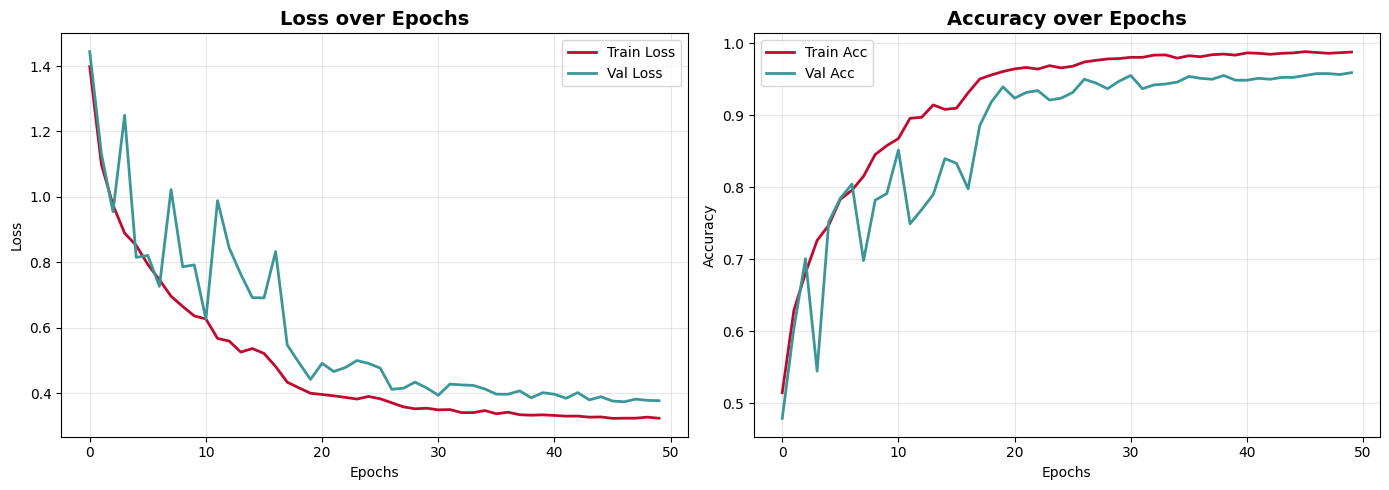

In [107]:
# Learning Curves

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='#BF092F', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='#3B9797', linewidth=2)
plt.title('Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='#BF092F', linewidth=2)
plt.plot(history['val_acc'], label='Val Acc', color='#3B9797', linewidth=2)
plt.title('Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Test Accuracy: 96.33%

Classification Report:
              precision    recall  f1-score   support

        fist       0.94      0.96      0.95        75
 double_fist       0.99      0.94      0.96        72
          up       0.96      0.96      0.96        77
        down       0.99      0.89      0.94        74
        left       0.96      0.97      0.97        75
       right       0.96      0.99      0.97        70
        rest       0.96      0.98      0.97       319

    accuracy                           0.96       762
   macro avg       0.96      0.96      0.96       762
weighted avg       0.96      0.96      0.96       762



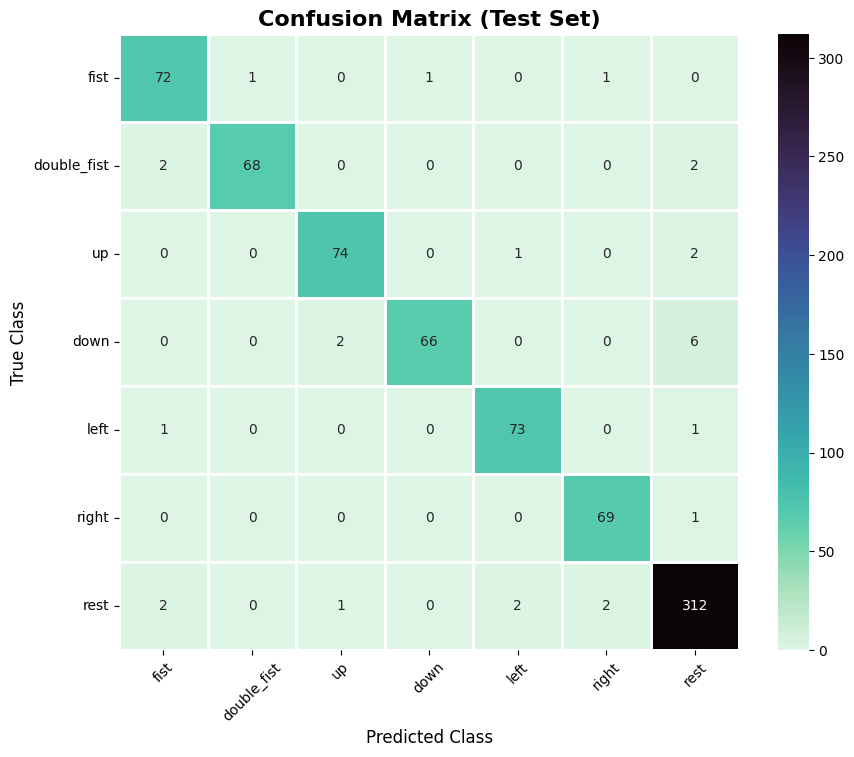

'torch.save({\n    \'model_state_dict\': model.state_dict(),\n    \'classes\': classes,\n    \'window_samples\': WINDOW_SAMPLES,\n    \'stride_samples\': STRIDE_SAMPLES,\n    \'num_channels\': NUM_CHANNELS\n}, "biowave_1d_cnn_model.pth")\nprint("Model saved to \'biowave_1d_cnn_model.pth\'")'

In [108]:
model.eval()
y_true = []
y_pred = []

# Run through test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Calculate Metrics
test_acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=list(range(len(classes))), target_names=classes, zero_division=0))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako_r', 
            xticklabels=classes, yticklabels=classes,
            linewidths=1, linecolor='white')
plt.title('Confusion Matrix (Test Set)', fontsize=16, fontweight='bold')
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


"""torch.save({
    'model_state_dict': model.state_dict(),
    'classes': classes,
    'window_samples': WINDOW_SAMPLES,
    'stride_samples': STRIDE_SAMPLES,
    'num_channels': NUM_CHANNELS
}, "biowave_1d_cnn_model.pth")
print("Model saved to 'biowave_1d_cnn_model.pth'")"""